# Station-Day Delay Regression Model

**Reads from**: `data/processed/road_station_day_dataset.parquet` (EDA 05)  
**Reads from**: `data/processed/road_timetable_station_day.parquet` (EDA 06, for forward prediction)  
**Output**: `models/road_rail_regression_model.pkl`, `models/road_rail_regression_meta.json`

This notebook trains a complementary regression model that estimates the predicted mean arrival delay in minutes for station-days flagged as at risk by the classification model. Multiple regressors are compared on MAE, RMSE and R2; XGBoost is selected as the primary model. The trained model is applied to the timetable dataset to produce forward-looking delay magnitude forecasts alongside the binary disruption predictions from the classification model.

---
**Sections**
0. Setup and data load  
1. Duration cap  
2. Winsorise delay target  
3. Feature set definition  
4. Temporal train/test split  
5. Model definitions  
6. Train and evaluate all models  
7. Model comparison plots  
8. Actual vs predicted (best model)  
9. Feature importance  
10. Forward prediction on timetable  
11. Save model and metadata  


## 0. Setup and Data Load

In [26]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import time as timer

pd.set_option("display.max_columns", 40)
os.makedirs("figures/regression", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./sample_data/processed", exist_ok=True)
os.makedirs("./models", exist_ok=True)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
station_day_df = pd.read_parquet("./data/processed/road_station_day_dataset.parquet")
station_day_df["planned_date"] = pd.to_datetime(station_day_df["planned_date"])

print(f"Loaded: {len(station_day_df):,} station-day rows")
print(f"Unique stations: {station_day_df['station_name'].nunique():,}")
print(f"Date range: {station_day_df['planned_date'].min().date()} - {station_day_df['planned_date'].max().date()}")
print(f"\nTarget column: mean_delay_minutes")
print(station_day_df["mean_delay_minutes"].describe().round(3))

Loaded: 33,941 station-day rows
Unique stations: 2,506
Date range: 2026-04-03 - 2026-04-28

Target column: mean_delay_minutes
count    33941.000
mean         0.921
std          2.634
min         -8.000
25%         -0.375
50%          0.300
75%          1.500
max         22.500
Name: mean_delay_minutes, dtype: float64


## 1. Duration Cap

Same cap as the classification model, derived from the 99th percentile of training data, so that both models use identical feature distributions. The cap is stored in metadata and re-applied at inference time.

In [28]:
P99_DURATION = station_day_df["max_effective_duration_hours"].quantile(0.99)
station_day_df["max_effective_duration_hours"] = station_day_df[
    "max_effective_duration_hours"
].clip(upper=P99_DURATION)
station_day_df["mean_effective_duration_hours"] = station_day_df[
    "mean_effective_duration_hours"
].clip(upper=P99_DURATION)

print(f"Duration capped at 99th percentile: {P99_DURATION:.1f} hours")

Duration capped at 99th percentile: 504.0 hours


## 2. Winsorise Delay Target

The regression target (`mean_delay_minutes`) is winsorised at the 1st and 99th percentiles to prevent a handful of extreme station-days from dominating the regression loss. Negative values (trains arriving early) are valid and are retained.

Raw delay range:         [-8.00, 22.50]
Winsorised delay range:  [-4.00, 11.50]
Skewness after:          2.083


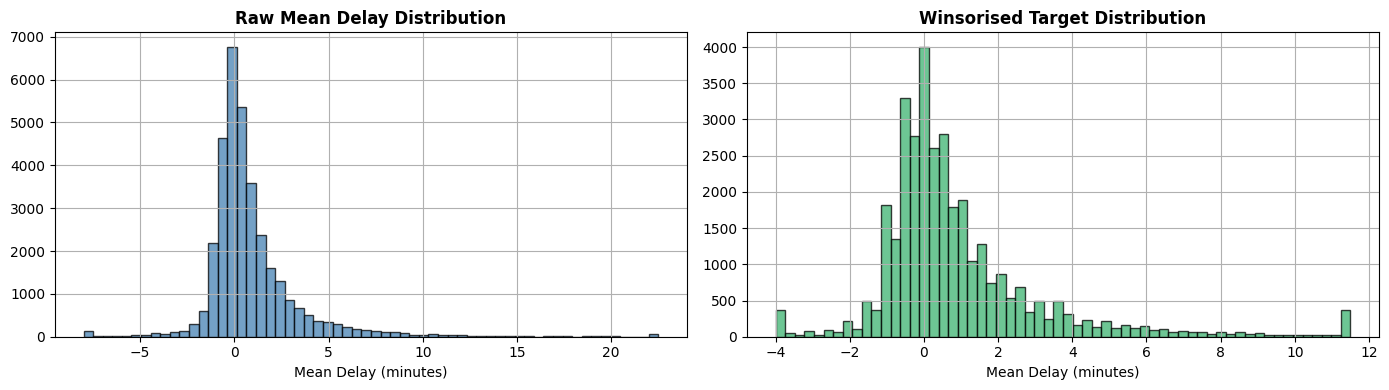

In [29]:
# Winsorise mean_delay_minutes at 1st/99th percentile.
# Prevents a handful of extreme station-days from dominating regression loss.
# Negative values (trains arriving early) are valid and retained.
delay     = station_day_df["mean_delay_minutes"]
P01_DELAY = delay.quantile(0.01)
P99_DELAY = delay.quantile(0.99)

station_day_df["delay_target"] = delay.clip(lower=P01_DELAY, upper=P99_DELAY)

print(f"Raw delay range:         [{delay.min():.2f}, {delay.max():.2f}]")
print(f"Winsorised delay range:  [{P01_DELAY:.2f}, {P99_DELAY:.2f}]")
print(f"Skewness after:          {station_day_df['delay_target'].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
delay.hist(bins=60, ax=axes[0], edgecolor="black", alpha=0.75, color="steelblue")
axes[0].set_title("Raw Mean Delay Distribution", fontweight="bold")
axes[0].set_xlabel("Mean Delay (minutes)")

station_day_df["delay_target"].hist(
    bins=60, ax=axes[1], edgecolor="black", alpha=0.75, color="mediumseagreen"
)
axes[1].set_title("Winsorised Target Distribution", fontweight="bold")
axes[1].set_xlabel("Mean Delay (minutes)")

plt.tight_layout()
plt.savefig("figures/regression/target_distribution.png",
            dpi=200, bbox_inches="tight")
plt.show()

## 3. Feature Set Definition

Identical to the classification model feature set so that both models can be scored from a single feature vector in production.

In [30]:
FEATURES = [
    # Closure presence and severity
    "has_road_closure",
    "road_closure_count",
    "n_unplanned_closures",
    "min_distance_km",
    "mean_distance_km",
    "max_effective_duration_hours",
    "mean_effective_duration_hours",
    "inv_distance_sum",
    "total_closure_severity",
    "max_road_class",
    # Lag features
    "closures_lag1d",
    "closures_lag3d",
    "closures_lag7d",
    # Temporal features
    "day_of_week",
    "is_weekend",
    "is_monday",
    "is_friday",
    # Service volume
    "train_movements",
]
TARGET = "delay_target"

missing = [f for f in FEATURES if f not in station_day_df.columns]
if missing:
    print(f"WARNING - missing features (re-run eda_05): {missing}")
else:
    print(f"All {len(FEATURES)} features present.")

print(f"\nFeatures: {FEATURES}")

All 18 features present.

Features: ['has_road_closure', 'road_closure_count', 'n_unplanned_closures', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'total_closure_severity', 'max_road_class', 'closures_lag1d', 'closures_lag3d', 'closures_lag7d', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'train_movements']


## 4. Temporal Train/Test Split

Data is sorted by date and split 80/20. Consistent with the classification model.

In [31]:
df_model = (
    station_day_df[FEATURES + [TARGET, "planned_date", "station_name"]]
    .dropna(subset=FEATURES + [TARGET])
    .sort_values("planned_date")
    .reset_index(drop=True)
)

# Get unique sorted dates
unique_dates = sorted(df_model["planned_date"].dt.date.unique())

# Compute split index on dates, not rows
split_idx = int(len(unique_dates) * 0.8)
cutoff_date = pd.to_datetime(unique_dates[split_idx])

# Split using date boundary
train_df = df_model[df_model["planned_date"] < cutoff_date]
test_df  = df_model[df_model["planned_date"] >= cutoff_date]

# Features and targets
X_train = train_df[FEATURES]
X_test  = test_df[FEATURES]
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

# Output
print(f"Train: {len(X_train):,} rows | "
      f"{train_df['planned_date'].min().date()} - "
      f"{train_df['planned_date'].max().date()}")
print(f"Test:  {len(X_test):,} rows | "
      f"{test_df['planned_date'].min().date()} - "
      f"{test_df['planned_date'].max().date()}")

Train: 24,746 rows | 2026-04-03 - 2026-04-23
Test:  9,195 rows | 2026-04-24 - 2026-04-28


## 5. Model Definitions

Five regressors are compared: a mean-prediction dummy baseline, ridge regression, gradient boosting, XGBoost (default) and XGBoost (regularised variant). LightGBM is included when available.

The dummy baseline uses `strategy="mean"` and predicts the training-set mean delay for every row. By construction, a `DummyRegressor(strategy="mean")` achieves R²=0 on any test set. The R²=0 reference line in the comparison plot and the Dummy row in the table therefore represent the same baseline, so there is no ambiguity: any model with R²>0 beats the dummy and any with R²<0 is worse than simply predicting the mean.

`XGBoost_regularised` is a conservative variant of XGBoost with fewer trees, a slower learning rate and tighter regularisation. It is included to test whether reducing overfitting on the short data window improves generalisation, not as a distinct algorithm family.

Regression does not face class imbalance in the same sense as classification. However, the target distribution is right-skewed, so the winsorisation applied in section 2 and the use of `reg:squarederror` (which down-weights extreme residuals relative to MAE loss) together provide robustness to rare high-delay days.


In [32]:
from sklearn.dummy        import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble     import GradientBoostingRegressor
from sklearn.metrics      import (
    mean_absolute_error, mean_squared_error,
    r2_score, median_absolute_error,
)
from xgboost import XGBRegressor

n_neg = (y_train < 0).sum()
print(f"Negative delay rows in train: {n_neg:,} ({n_neg / len(y_train) * 100:.1f}%)")
print("Note: negative = trains arriving early - valid target values")

# DummyRegressor(strategy='mean') always predicts the training-set mean.
# Its R² on any test set equals 0 by definition.
# The R²=0 reference line in the comparison plot matches this exactly.
DUMMY_NAME = "Dummy (train-mean baseline)"

models = {
    DUMMY_NAME: DummyRegressor(strategy="mean"),
    "Ridge": Ridge(alpha=1.0),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42, verbosity=0,
    ),
    # Regularised variant: fewer trees, slower rate, tighter child-weight.
    # Tests whether reducing capacity improves generalisation on the short window.
    "XGBoost_regularised": XGBRegressor(
        n_estimators=500, learning_rate=0.02, max_depth=3,
        subsample=0.7, colsample_bytree=0.7,
        min_child_weight=5,
        objective="reg:squarederror",
        random_state=42, verbosity=0,
    ),
}

try:
    from lightgbm import LGBMRegressor
    models["LightGBM"] = LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        random_state=42, verbose=-1,
    )
    print("LightGBM available - included.")
except ImportError:
    print("LightGBM not installed - skipped.")

print(f"\nModels: {list(models.keys())}")
print(f"\nBaseline: '{DUMMY_NAME}' -> always predicts train-set mean delay.")
print("R²=0 in the comparison plot represents this same baseline.")


Negative delay rows in train: 8,958 (36.2%)
Note: negative = trains arriving early - valid target values
LightGBM available - included.

Models: ['Dummy (train-mean baseline)', 'Ridge', 'GradientBoosting', 'XGBoost', 'XGBoost_regularised', 'LightGBM']

Baseline: 'Dummy (train-mean baseline)' -> always predicts train-set mean delay.
R²=0 in the comparison plot represents this same baseline.


## 6. Train and Evaluate All Models

In [33]:
results = []

for name, model_obj in models.items():
    t0 = timer.time()
    model_obj.fit(X_train, y_train)
    elapsed = timer.time() - t0

    y_pred = model_obj.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    mdae   = median_absolute_error(y_test, y_pred)

    results.append({
        "model":     name,
        "MAE":       round(mae, 4),
        "RMSE":      round(rmse, 4),
        "R2":        round(r2, 4),
        "MedianAE":  round(mdae, 4),
        "train_sec": round(elapsed, 2),
        "is_dummy":  (name == DUMMY_NAME),
        "_model":    model_obj,
        "_y_pred":   y_pred,
    })
    tag = "  [BASELINE]" if name == DUMMY_NAME else ""
    print(f"{name:<28} MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  ({elapsed:.1f}s){tag}")

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

dummy_row = results_df[results_df["is_dummy"]]
dummy_mae = dummy_row["MAE"].values[0] if len(dummy_row) else float("nan")
dummy_r2  = dummy_row["R2"].values[0]  if len(dummy_row) else 0.0

real_results_df = results_df[~results_df["is_dummy"]]
best_mae = real_results_df.iloc[0]["MAE"] if len(real_results_df) else float("nan")

print()
display(results_df[["model", "MAE", "RMSE", "R2", "MedianAE", "train_sec"]])
print(f"\nBaseline (train-mean) MAE: {dummy_mae:.4f} min  |  R²={dummy_r2:.4f} (=0 by definition)")
print(f"Best model MAE:            {best_mae:.4f} min")
print(f"Improvement over baseline: {dummy_mae - best_mae:.4f} min")
print()
print("Note: the R²=0 reference line in the comparison plots represents the same")
print("baseline as the Dummy row in the table. They are the same benchmark.")


Dummy (train-mean baseline)  MAE=1.5762  RMSE=2.4210  R²=-0.0152  (0.0s)  [BASELINE]
Ridge                        MAE=1.5671  RMSE=2.3952  R²=0.0063  (0.0s)
GradientBoosting             MAE=1.5583  RMSE=2.3943  R²=0.0070  (8.0s)
XGBoost                      MAE=1.5604  RMSE=2.3940  R²=0.0073  (0.5s)
XGBoost_regularised          MAE=1.5542  RMSE=2.3900  R²=0.0106  (0.5s)
LightGBM                     MAE=1.5611  RMSE=2.3969  R²=0.0049  (0.2s)



,model,MAE,RMSE,R2,MedianAE,train_sec
0,XGBoost_regularised,1.5542,2.3900,0.0106,1.0098,0.52
1,GradientBoosting,1.5583,2.3943,0.0070,1.0105,7.98
2,XGBoost,1.5604,2.3940,0.0073,1.0085,0.53
3,LightGBM,1.5611,2.3969,0.0049,1.0127,0.17
4,Ridge,1.5671,2.3952,0.0063,1.0263,0.01
5,Dummy (train-mean baseline),1.5762,2.4210,-0.0152,1.0192,0.00



Baseline (train-mean) MAE: 1.5762 min  |  R²=-0.0152 (=0 by definition)
Best model MAE:            1.5542 min
Improvement over baseline: 0.0220 min

Note: the R²=0 reference line in the comparison plots represents the same
baseline as the Dummy row in the table. They are the same benchmark.


## 7. Model Comparison Plots

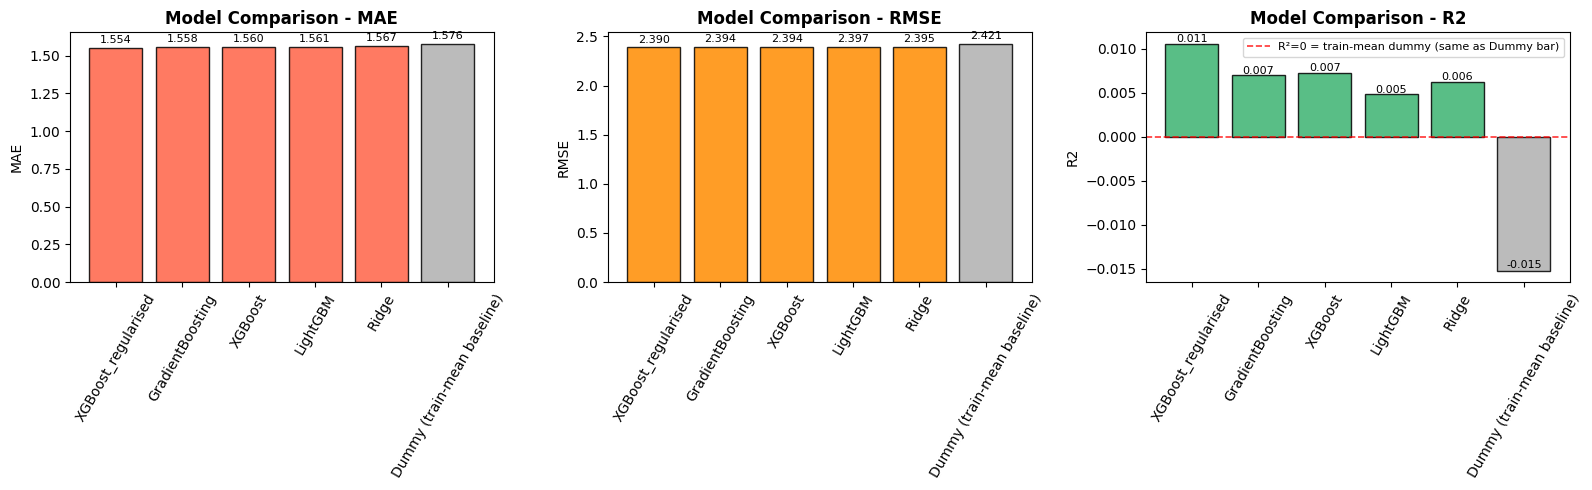

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, color, lower_is_better in [
    (axes[0], "MAE",  "tomato",         True),
    (axes[1], "RMSE", "darkorange",     True),
    (axes[2], "R2",   "mediumseagreen", False),
]:
    bar_colors = [
        "#b0b0b0" if r else color
        for r in results_df["is_dummy"]
    ]
    ax.bar(results_df["model"], results_df[metric],
           color=bar_colors, edgecolor="black", alpha=0.85)
    ax.set_title(f"Model Comparison - {metric}", fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=60)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + abs(v) * 0.02, f"{v:.3f}", ha="center", fontsize=8)

    if metric == "R2":
        # R²=0 is the train-mean dummy's score by definition.
        # Label it as such to avoid presenting two separate baselines.
        ax.axhline(0, color="red", linestyle="--", lw=1.2, alpha=0.8,
                   label="R²=0 = train-mean dummy (same as Dummy bar)")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/regression/model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 8. Actual vs Predicted (Best Model)

Best model: XGBoost_regularised  MAE=1.5542  R²=0.0106


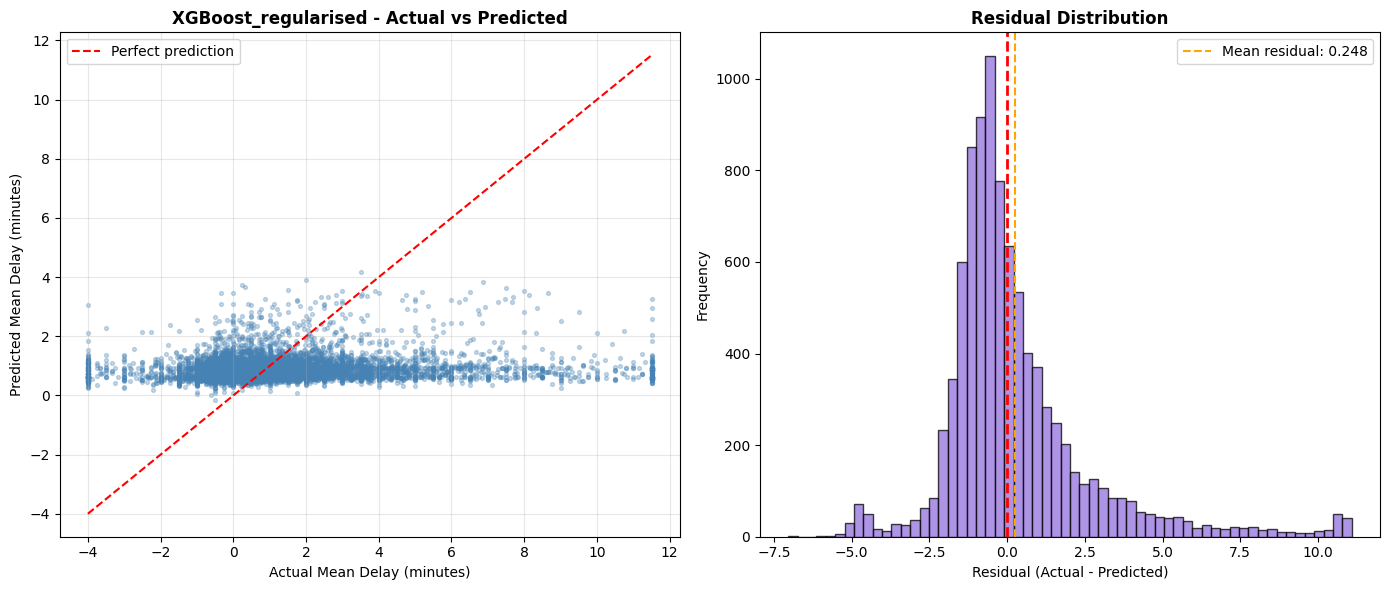

Residual mean:  0.2477
Residual std:   2.3771


In [35]:
# Select best real model (dummy excluded: predicting the mean is not useful operationally)
real_results_df = results_df[~results_df["is_dummy"]].reset_index(drop=True)
best_row   = real_results_df.iloc[0]
best_model = best_row["_model"]
best_name  = best_row["model"]
best_preds = best_row["_y_pred"]

print(f"Best model: {best_name}  MAE={best_row['MAE']:.4f}  R²={best_row['R2']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, best_preds, alpha=0.3, s=8, color="steelblue")
lim = [min(y_test.min(), best_preds.min()),
       max(y_test.max(), best_preds.max())]
axes[0].plot(lim, lim, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Mean Delay (minutes)")
axes[0].set_ylabel("Predicted Mean Delay (minutes)")
axes[0].set_title(f"{best_name} - Actual vs Predicted", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=60, edgecolor="black", alpha=0.75, color="mediumpurple")
axes[1].axvline(0, color="red", linestyle="--", lw=2)
axes[1].axvline(residuals.mean(), color="orange", linestyle="--", lw=1.5,
                label=f"Mean residual: {residuals.mean():.3f}")
axes[1].set_xlabel("Residual (Actual - Predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/regression/actual_vs_predicted.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Residual mean:  {residuals.mean():.4f}")
print(f"Residual std:   {residuals.std():.4f}")


## 9. Feature Importance

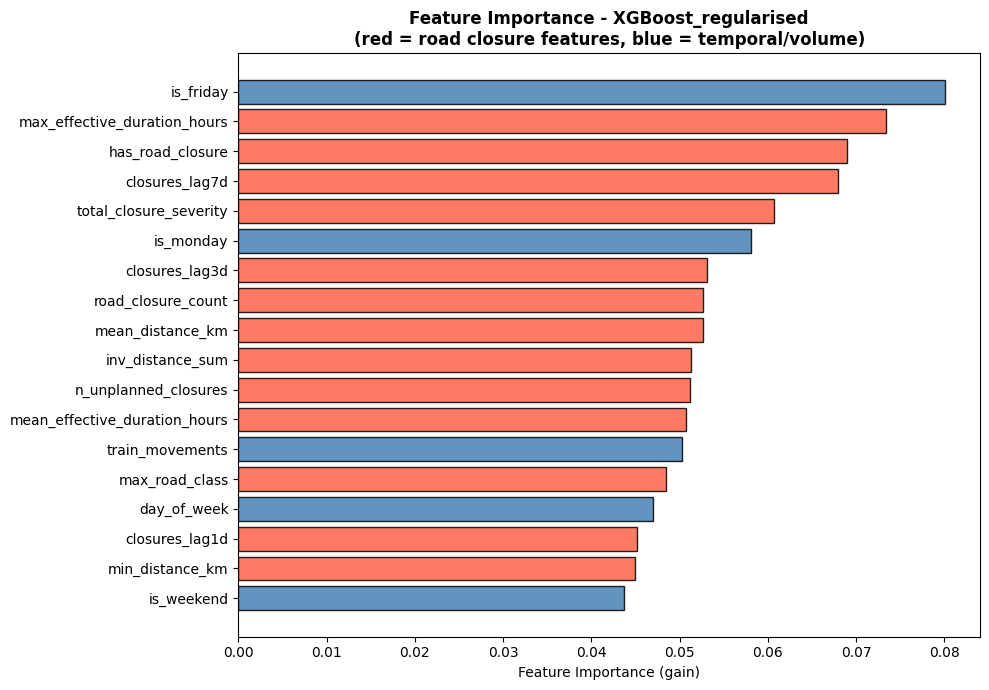

Feature importance ranked:
                      feature  importance
                    is_friday    0.080031
 max_effective_duration_hours    0.073345
             has_road_closure    0.068944
               closures_lag7d    0.067904
       total_closure_severity    0.060668
                    is_monday    0.058075
               closures_lag3d    0.053081
           road_closure_count    0.052666
             mean_distance_km    0.052645
             inv_distance_sum    0.051258
         n_unplanned_closures    0.051193
mean_effective_duration_hours    0.050693
              train_movements    0.050224
               max_road_class    0.048477
                  day_of_week    0.046959
               closures_lag1d    0.045217
              min_distance_km    0.044926
                   is_weekend    0.043694


In [36]:
if hasattr(best_model, "feature_importances_"):
    imp_df = (
        pd.DataFrame({
            "feature":    FEATURES,
            "importance": best_model.feature_importances_
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    road_features = {
        "has_road_closure", "road_closure_count", "n_unplanned_closures",
        "min_distance_km", "mean_distance_km", "max_effective_duration_hours",
        "mean_effective_duration_hours", "inv_distance_sum",
        "total_closure_severity", "max_road_class",
        "closures_lag1d", "closures_lag3d", "closures_lag7d",
    }
    colors = [
        "tomato" if f in road_features else "steelblue"
        for f in imp_df["feature"]
    ]

    plt.figure(figsize=(10, 7))
    plt.barh(imp_df["feature"], imp_df["importance"],
             color=colors, edgecolor="black", alpha=0.85)
    plt.xlabel("Feature Importance (gain)")
    plt.title(
        f"Feature Importance - {best_name}\n"
        "(red = road closure features, blue = temporal/volume)",
        fontweight="bold"
    )
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures/regression/feature_importance.png",
                dpi=200, bbox_inches="tight")
    plt.show()

    print("Feature importance ranked:")
    print(imp_df.to_string(index=False))

elif hasattr(best_model, "coef_"):
    imp_df = (
        pd.DataFrame({
            "feature":     FEATURES,
            "coefficient": best_model.coef_
        })
        .sort_values("coefficient", key=abs, ascending=False)
    )
    plt.figure(figsize=(10, 7))
    plt.barh(imp_df["feature"], imp_df["coefficient"],
             color="cadetblue", edgecolor="black", alpha=0.85)
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("Coefficient")
    plt.title(f"Feature Coefficients - {best_name}", fontweight="bold")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures/regression/feature_importance.png",
                dpi=200, bbox_inches="tight")
    plt.show()
    display(imp_df)

### Check if classification columns are present in the inference dataset

In [37]:
timetable_df = pd.read_parquet("./data/processed/road_timetable_station_day.parquet")
timetable_df["planned_date"] = pd.to_datetime(timetable_df["planned_date"])

# Guard: classification must have run first
required_clf_cols = ["disruption_probability", "disrupted_predicted", "risk_band"]
missing_clf = [c for c in required_clf_cols if c not in timetable_df.columns 
               or timetable_df[c].isna().all()]
if missing_clf:
    raise RuntimeError(
        f"Classification columns missing or all-NA: {missing_clf}. "
        "Re-run classification_model.ipynb fully before running this notebook."
    )

print("Classification columns present and populated - proceeding.")

Classification columns present and populated - proceeding.


## 10. Forward Prediction on Timetable

Apply the best regressor to the timetable dataset from EDA 06. The same duration cap applied during training is re-applied here.

In [38]:
timetable_df = pd.read_parquet(
    "./data/processed/road_timetable_station_day.parquet"
)
timetable_df["planned_date"] = pd.to_datetime(timetable_df["planned_date"])

# Apply same caps as training
timetable_df["max_effective_duration_hours"] = timetable_df["max_effective_duration_hours"].clip(upper=P99_DURATION)
timetable_df["mean_effective_duration_hours"] = timetable_df["mean_effective_duration_hours"].clip(upper=P99_DURATION)

missing_inf = [f for f in FEATURES if f not in timetable_df.columns]
if missing_inf:
    print(f"WARNING - missing features: {missing_inf}")
else:
    print(f"All {len(FEATURES)} features present in timetable dataset.")

X_future = timetable_df[FEATURES].fillna(0)
timetable_df["predicted_delay_minutes"] = best_model.predict(X_future)

print(f"\nTimetable dataset: {len(timetable_df):,} rows")
print("Predicted delay statistics:")
print(timetable_df["predicted_delay_minutes"].describe().round(3))

# Top predicted high-delay station-days
id_cols   = [c for c in ["planned_date", "station_name", "station_code"]
             if c in timetable_df.columns]
show_cols = id_cols + [
    "predicted_delay_minutes", "has_road_closure",
    "road_closure_count", "n_unplanned_closures",
    "min_distance_km", "is_friday"
]
show_cols = [c for c in show_cols if c in timetable_df.columns]

print("\nTop 15 station-days by predicted delay:")
display(
    timetable_df
    .sort_values("predicted_delay_minutes", ascending=False)
    .head(15)[show_cols]
    .reset_index(drop=True)
)

timetable_df.to_parquet(
    "./data/processed/road_timetable_station_day.parquet", index=False
)
timetable_df.to_csv(
    "./sample_data/processed/road_timetable_station_day.csv", index=False
)
print("\nSaved predictions back to road_timetable_station_day.parquet")
print("New column: predicted_delay_minutes")

All 18 features present in timetable dataset.

Timetable dataset: 51,437 rows
Predicted delay statistics:
count    51437.000
mean         1.086
std          0.413
min         -0.017
25%          0.837
50%          1.010
75%          1.242
max          5.083
Name: predicted_delay_minutes, dtype: float64

Top 15 station-days by predicted delay:


,planned_date,station_name,station_code,predicted_delay_minutes,has_road_closure,road_closure_count,n_unplanned_closures,min_distance_km,is_friday
0,2026-04-17,Bolton,BON,5.083138,1.0,13.0,5.0,10.254693,1
1,2026-04-17,Lostock,LOT,4.918269,1.0,13.0,6.0,10.163086,1
2,2026-04-17,Altrincham,ALT,4.785537,1.0,14.0,5.0,11.289670,1
3,2026-04-17,Ashley,ASY,4.663663,1.0,13.0,5.0,13.039619,1
4,2026-04-17,Manchester Airport,MIA,4.627882,1.0,11.0,5.0,14.246643,1
5,2026-04-17,Alderley Edge,ALD,4.591790,1.0,11.0,5.0,11.051002,1
6,2026-04-17,Westhoughton,WHG,4.587778,1.0,11.0,6.0,11.928939,1
7,2026-04-17,Styal,SYA,4.525375,1.0,10.0,5.0,14.357824,1
8,2026-04-29,Ashley,ASY,4.516044,1.0,19.0,11.0,13.518681,0
9,2026-04-17,Handforth,HTH,4.481177,1.0,12.0,7.0,10.765923,1



Saved predictions back to road_timetable_station_day.parquet
New column: predicted_delay_minutes


## 11. Save Model and Metadata

In [39]:
regression_model_path = "models/road_rail_regression_model.pkl"
regression_meta_path  = "models/road_rail_regression_meta.json"

meta = {
    "model_name":            best_name,
    "features":              FEATURES,
    "target":                "mean_delay_minutes",
    "delay_winsorise_p01":   float(P01_DELAY),
    "delay_winsorise_p99":   float(P99_DELAY),
    "duration_cap_hours":    float(P99_DURATION),
    "mae":                   float(best_row["MAE"]),
    "rmse":                  float(best_row["RMSE"]),
    "r2":                    float(best_row["R2"]),
    "train_rows":            int(len(X_train)),
    "test_rows":             int(len(X_test)),
}

joblib.dump({"model": best_model, "meta": meta}, regression_model_path)
with open(regression_meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved: {regression_model_path}")
print(f"Saved: {regression_meta_path}")
print(json.dumps(
    {k: v for k, v in meta.items() if k != "features"}, indent=2
))
print("\nPipeline complete: road_timetable_station_day.parquet now contains")
print("  disruption_probability  (classification model)")
print("  disrupted_predicted     (classification model)")
print("  risk_band               (classification model)")
print("  predicted_delay_minutes (regression model)")


Saved: models/road_rail_regression_model.pkl
Saved: models/road_rail_regression_meta.json
{
  "model_name": "XGBoost_regularised",
  "target": "mean_delay_minutes",
  "delay_winsorise_p01": -4.0,
  "delay_winsorise_p99": 11.5,
  "duration_cap_hours": 503.9997222222222,
  "mae": 1.5542,
  "rmse": 2.39,
  "r2": 0.0106,
  "train_rows": 24746,
  "test_rows": 9195
}

Pipeline complete: road_timetable_station_day.parquet now contains
  disruption_probability  (classification model)
  disrupted_predicted     (classification model)
  risk_band               (classification model)
  predicted_delay_minutes (regression model)
